In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../data/raw/medical_insurance.csv")


Dataset Overview

In [29]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [30]:
df.tail()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,...,0,0,0,0,0,1,1,1,0,0


In [31]:
df.sample(5)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
15580,81057,61,Female,West,Urban,28300.0,HS,Married,Employed,3,...,0,0,0,2,0,1,2,0,1,0
41881,29008,40,Female,East,Urban,6400.0,Bachelors,Single,Self-employed,1,...,0,0,0,2,0,0,0,0,0,0
9640,9660,50,Female,East,Urban,43600.0,Bachelors,Single,Employed,1,...,0,0,0,0,0,0,0,0,1,0
37978,25469,36,Female,Central,Urban,21100.0,Some College,Married,Employed,3,...,0,1,0,1,0,0,1,1,1,0
52113,60951,66,Male,South,Urban,26700.0,Bachelors,Widowed,Self-employed,1,...,0,1,0,2,0,1,0,1,1,0


In [32]:
df.shape

(100000, 54)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


In [35]:
missing = df.isnull().sum()

missing[missing > 0]

alcohol_freq    30083
dtype: int64

In [36]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [37]:
df.nunique().sort_values(ascending=False)

person_id                      100000
annual_medical_cost             91299
total_claims_paid               56650
annual_premium                  55538
avg_claim_amount                53071
monthly_premium                 12339
income                           2987
ldl                              1881
hba1c                             732
provider_quality                  350
bmi                               340
systolic_bp                       119
age                               101
risk_score                         92
diastolic_bp                       72
claims_count                       22
visits_last_year                   22
days_hospitalized_last_3yrs        16
medication_count                   12
policy_term_years                  10
household_size                      9
dependents                          8
proc_imaging_count                  8
proc_physio_count                   8
proc_lab_count                      8
proc_consult_count                  8
proc_surgery

Univariate Analysis


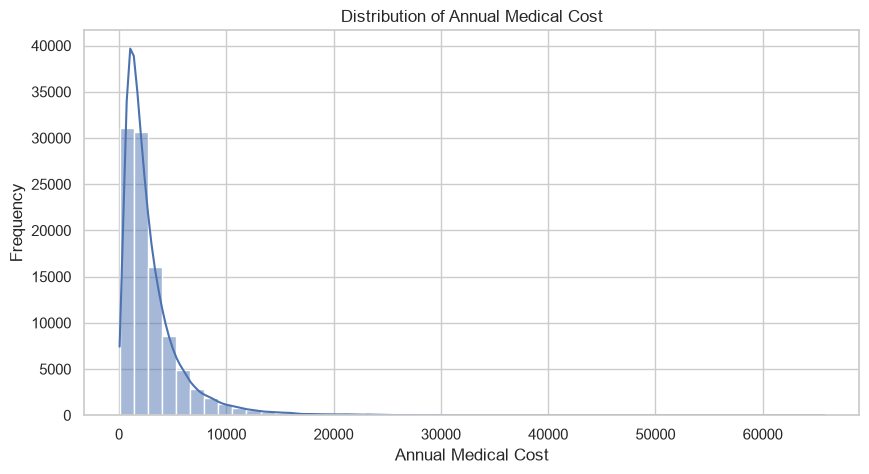

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="annual_medical_cost",
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Medical Cost")
plt.xlabel("Annual Medical Cost")
plt.ylabel("Frequency")

plt.show()

### 📊 Chart: Histogram with KDE

**Purpose:** Used to visualize the distribution of a numerical variable and identify its overall pattern.

### 📊 Observations
- Most annual medical costs are concentrated at lower values.
- The distribution is right-skewed with a few high-cost values.

### 🔍 Pattern
- Most patients have lower medical expenses, while only a few have very high costs.

### 🤖 ML Impact
- The skewed distribution may affect model performance.
- A log transformation of the target variable can improve prediction accuracy.

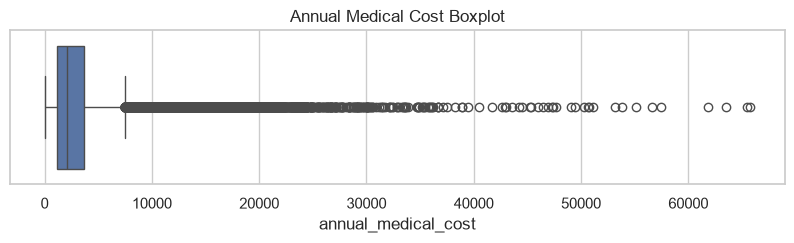

In [6]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["annual_medical_cost"]
)

plt.title("Annual Medical Cost Boxplot")

plt.show()

📊 Chart: Box Plot

**Purpose:** Used to visualize the distribution of numerical data and identify outliers.

📊 Observations
- Most medical costs are concentrated in the lower range.
- Several high-cost outliers are present.

🔍 Pattern
- The data is right-skewed with many extreme medical cost values.

🤖 ML Impact
- Outliers may affect model performance.
- Outlier treatment or robust models should be considered.

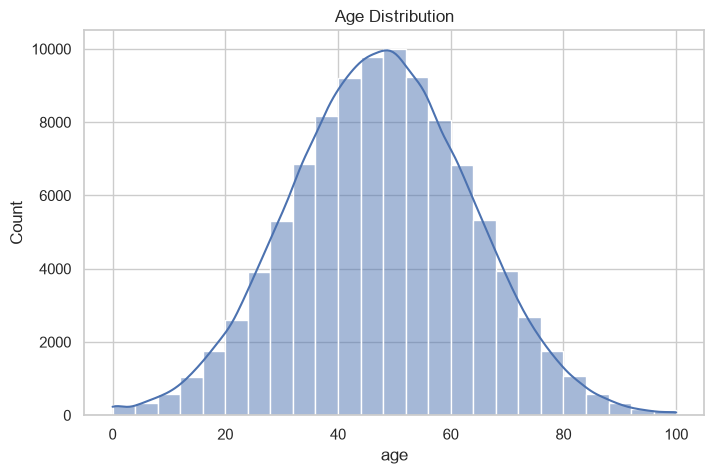

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=25,
    kde=True
)

plt.title("Age Distribution")

plt.show()

### 📊 Chart: Histogram with KDE

**Purpose:** Used to visualize the distribution of the `age` variable.

### 📊 Observations
- Most individuals are between **35–60 years** of age.
- The age distribution is approximately **normal (bell-shaped)**.

### 🔍 Pattern
- The dataset contains a balanced spread of ages with no major skewness.

### 🤖 ML Impact
- Since age is nearly normally distributed, it is unlikely to require transformation.
- This feature can be directly used for model training.

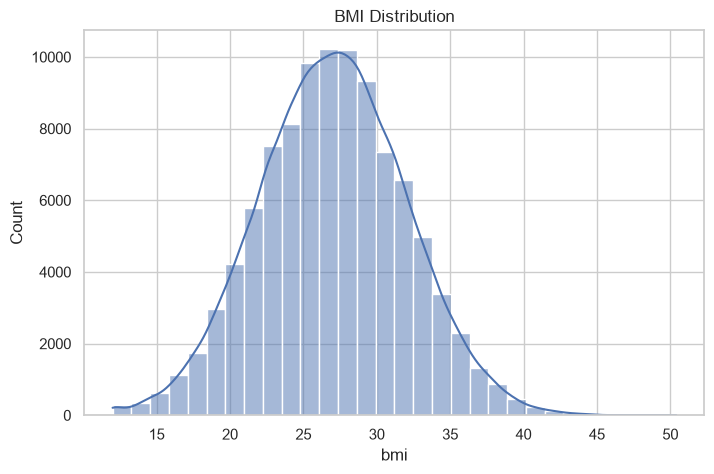

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="bmi",
    bins=30,
    kde=True
)

plt.title("BMI Distribution")

plt.show()

### 📊 Chart: Histogram with KDE

**Purpose:** Used to visualize the distribution of the `bmi` variable.

### 📊 Observations
- Most BMI values are between **22–32**.
- The BMI distribution is approximately **normal (bell-shaped)**.

### 🔍 Pattern
- BMI values are evenly distributed around the average with few extreme values.

### 🤖 ML Impact
- BMI can be directly used for model training.
- No major transformation is required.

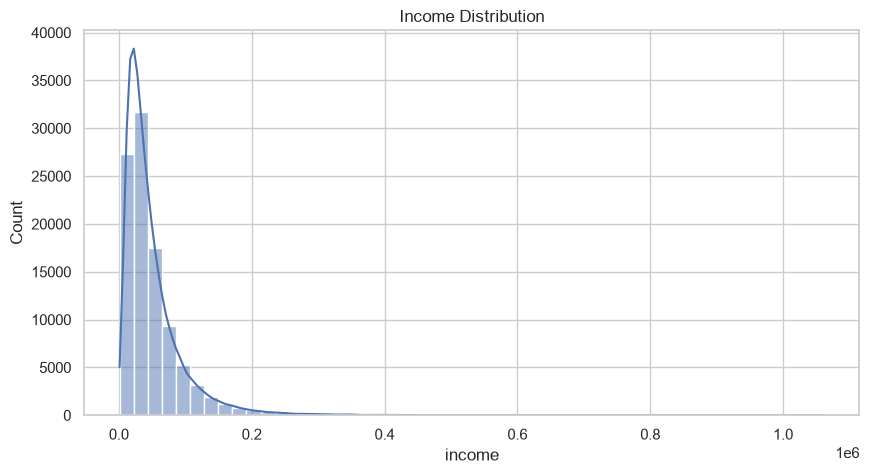

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="income",
    bins=50,
    kde=True
)

plt.title("Income Distribution")

plt.show()

### 📊 Chart: Histogram with KDE

**Purpose:** Used to visualize the distribution of the `income` variable.

### 📊 Observations
- Most individuals have lower income levels.
- The income distribution is **right-skewed** with a few high-income values.

### 🔍 Pattern
- Income decreases in frequency as income increases, indicating a small number of high-income individuals.

### 🤖 ML Impact
- The skewed distribution may affect model performance.
- A log transformation can improve prediction accuracy.


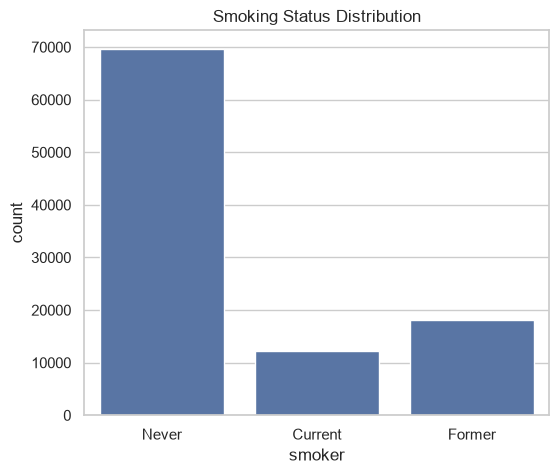

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="smoker"
)

plt.title("Smoking Status Distribution")

plt.show()

### 📊 Chart: Count Plot

**Purpose:** Used to visualize the distribution of the `smoker` categories.

### 📊 Observations
- Most individuals are **Never** smokers.
- **Current** smokers are the smallest group.

### 🔍 Pattern
- The smoking status is imbalanced, with **Never** smokers dominating the dataset.

### 🤖 ML Impact
- Class imbalance may affect the model.
- Encoding categorical values is required before training.

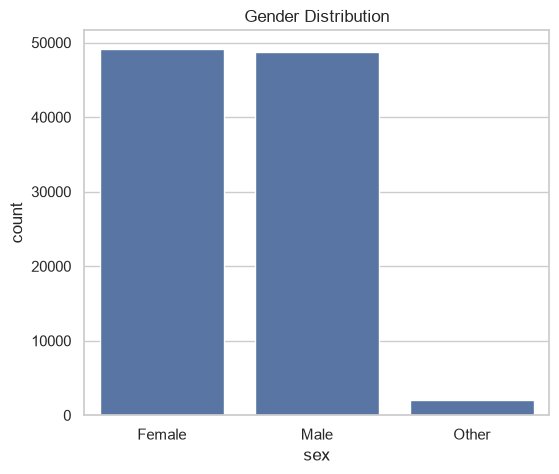

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Gender Distribution")

plt.show()

### 📊 Chart: Count Plot

**Purpose:** Used to visualize the distribution of the `sex` variable.

### 📊 Observations
- Male and Female counts are nearly equal.
- The **Other** category has very few records.

### 🔍 Pattern
- The dataset is balanced for Male and Female but underrepresented for the Other category.

### 🤖 ML Impact
- The `sex` feature should be encoded before model training.
- The small **Other** category may have limited impact on the model.

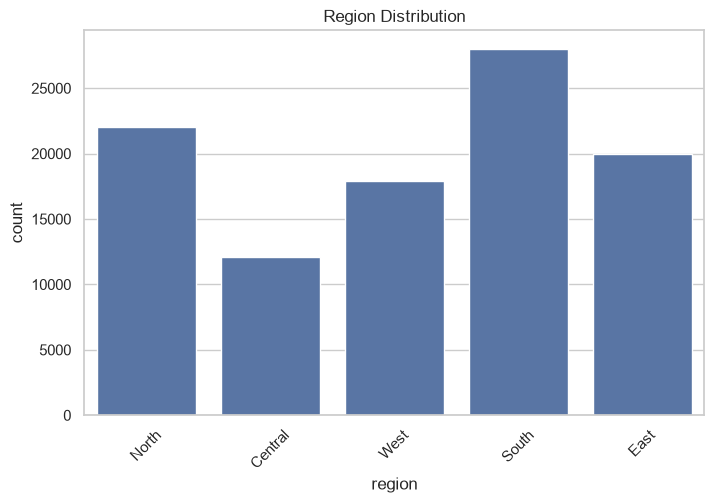

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="region"
)

plt.xticks(rotation=45)

plt.title("Region Distribution")

plt.show()

### 📊 Chart: Count Plot

**Purpose:** Used to visualize the distribution of the `region` variable.

### 📊 Observations
- The **South** region has the highest number of records.
- The **Central** region has the lowest number of records.

### 🔍 Pattern
- The distribution of records varies across regions, with South being the most represented.

### 🤖 ML Impact
- The `region` feature should be encoded before model training.
- Uneven category distribution may slightly influence the model.

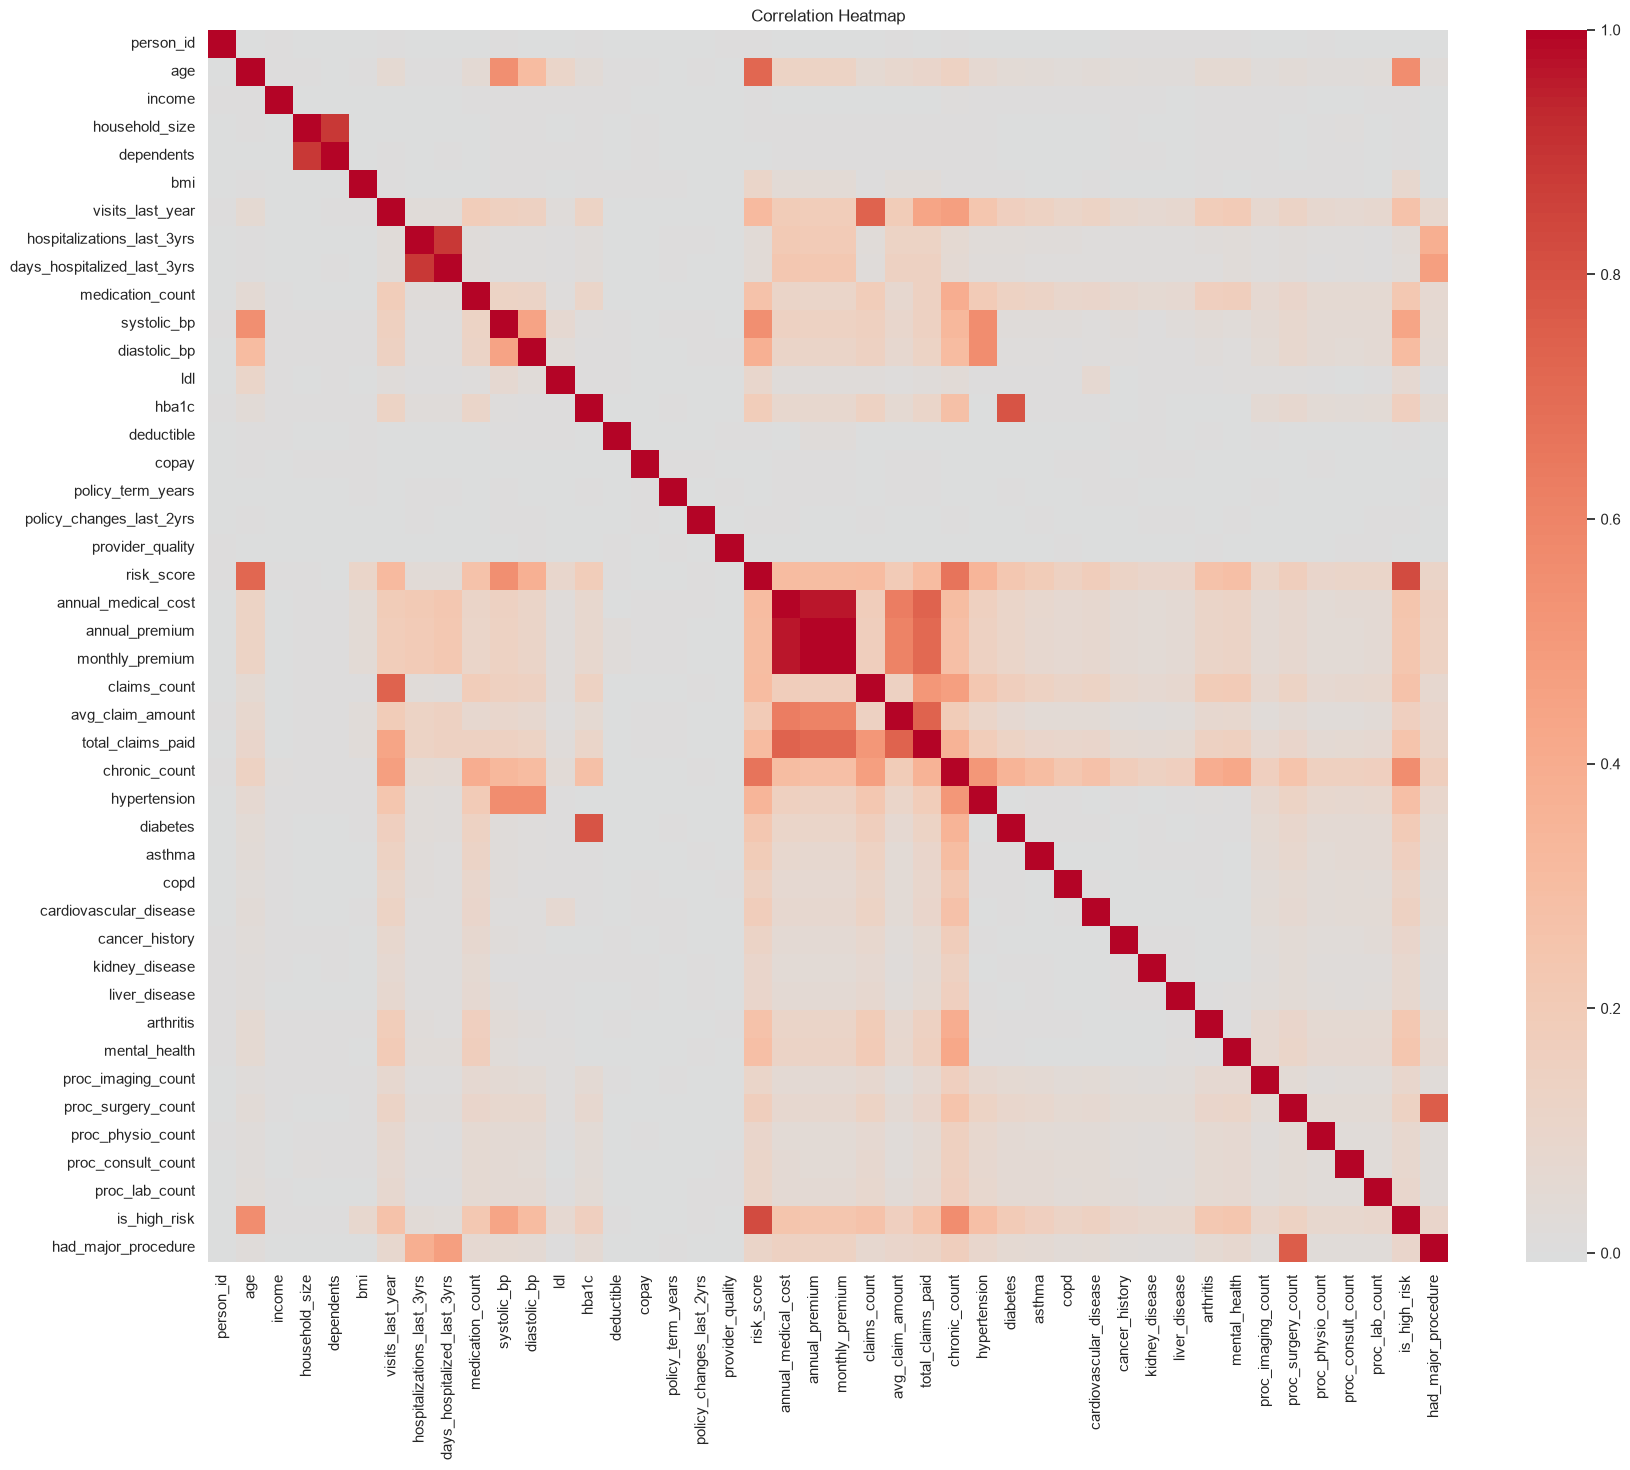

In [13]:
plt.figure(figsize=(20,16))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

### 📊 Chart: Correlation Heatmap

**Purpose:** Used to visualize the correlation between numerical features.

### 📊 Observations
- Most features have weak to moderate correlations.
- A few feature pairs show strong positive correlations.

### 🔍 Pattern
- Highly correlated features may contain similar information.

### 🤖 ML Impact
- Strongly correlated features can cause multicollinearity.
- Feature selection or dimensionality reduction may improve model performance.

BIVARIATE-ANALYSIS



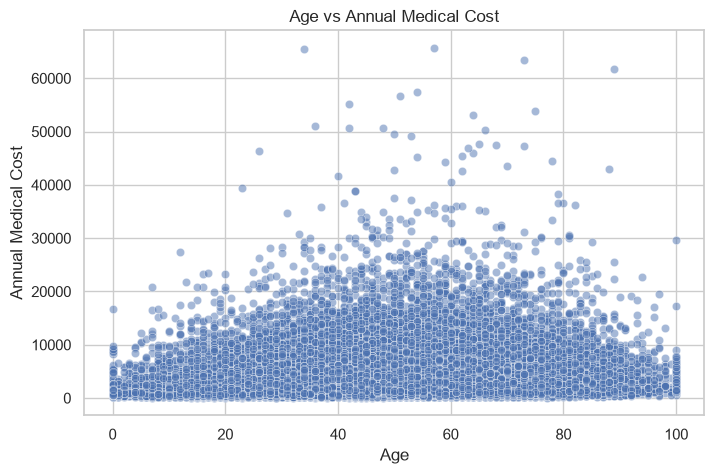

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="annual_medical_cost",
    alpha=0.5
)

plt.title("Age vs Annual Medical Cost")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to visualize the relationship between `age` and `annual_medical_cost`.

### 📊 Observations
- Medical cost generally increases with age.
- A few individuals have very high medical costs.
- High-cost cases are mostly seen in middle and older age groups.

### 🔍 Pattern
- A weak positive relationship exists between age and medical cost.

### 🤖 ML Impact
- Age is a useful feature for predicting medical cost.
- Other factors also influence cost, so age alone is not sufficient.

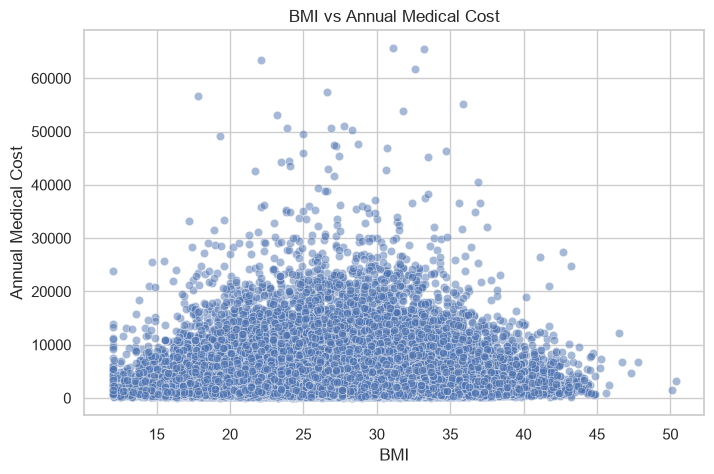

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="annual_medical_cost",
    alpha=0.5
)

plt.title("BMI vs Annual Medical Cost")
plt.xlabel("BMI")
plt.ylabel("Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to visualize the relationship between `BMI` and `annual_medical_cost`.

### 📊 Observations
- Medical cost tends to increase with BMI.
- Several high-cost cases are seen at higher BMI values.
- A few outliers have extremely high medical costs.

### 🔍 Pattern
- A weak positive relationship exists between BMI and medical cost.

### 🤖 ML Impact
- BMI is an important feature for predicting medical cost.
- Other features also influence the final prediction.

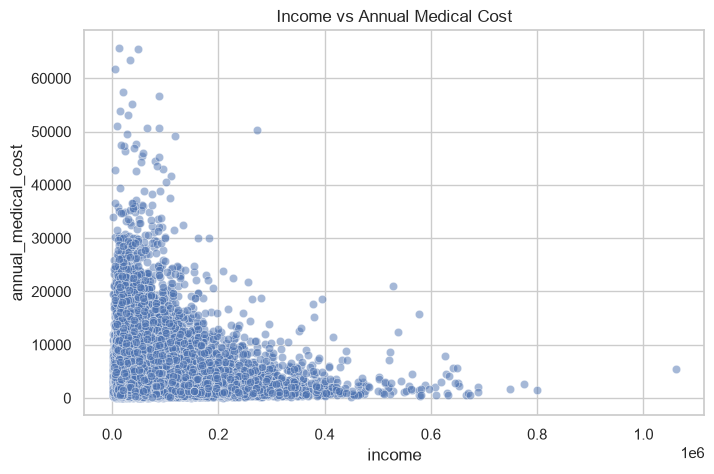

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="income",
    y="annual_medical_cost",
    alpha=0.5
)

plt.title("Income vs Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to visualize the relationship between `income` and `annual_medical_cost`.

### 📊 Observations
- Most individuals have lower income and lower medical costs.
- High-income individuals are fewer in number.
- A few high-cost outliers are present.

### 🔍 Pattern
- There is a weak relationship between income and medical cost.

### 🤖 ML Impact
- Income alone is not a strong predictor of medical cost.
- Other features should be combined for better predictions.

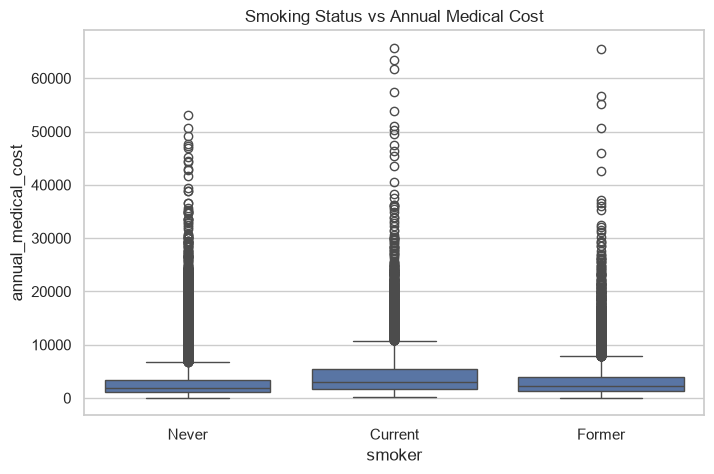

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="annual_medical_cost"
)

plt.title("Smoking Status vs Annual Medical Cost")

plt.show()

### 📊 Chart: Box Plot

**Purpose:** Used to compare annual medical costs across different smoking categories.

### 📊 Observations
- Current smokers have the highest median medical cost.
- Never smokers have the lowest median medical cost.
- All groups contain some high-cost outliers.

### 🔍 Pattern
- Medical costs are generally higher for current smokers than for former or never smokers.

### 🤖 ML Impact
- Smoking status is an important predictor of medical cost.
- The categorical feature should be encoded before model training.

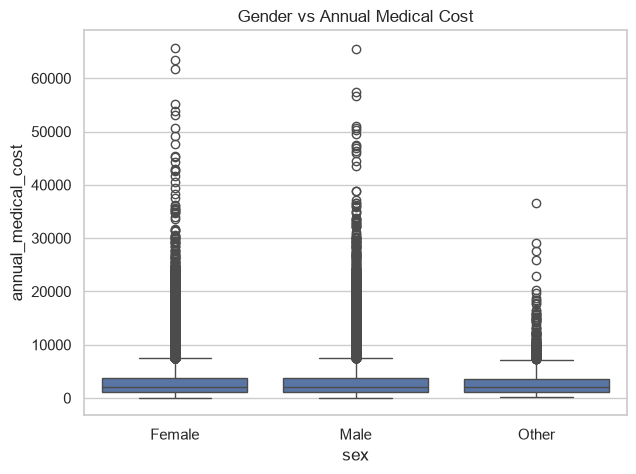

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="sex",
    y="annual_medical_cost"
)

plt.title("Gender vs Annual Medical Cost")

plt.show()

### 📊 Chart: Box Plot

**Purpose:** Used to compare annual medical costs across different genders.

### 📊 Observations
- Male and Female have similar median medical costs.
- The Other category has fewer records and fewer outliers.

### 🔍 Pattern
- Medical costs are similar across genders with no major difference.

### 🤖 ML Impact
- Gender has a relatively small impact on medical cost.
- The `sex` feature should be encoded before model training.

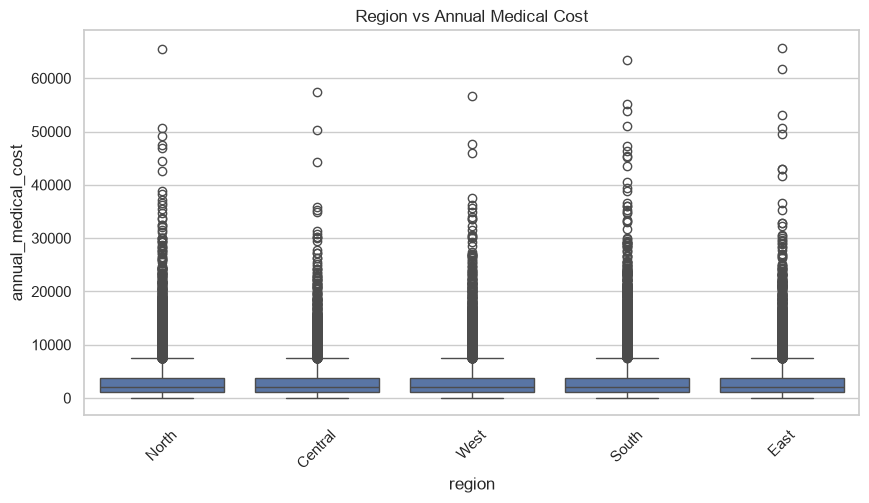

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="region",
    y="annual_medical_cost"
)

plt.xticks(rotation=45)

plt.title("Region vs Annual Medical Cost")

plt.show()

### 📊 Chart: Box Plot

**Purpose:** Used to compare annual medical costs across different regions.

### 📊 Observations
- The South region has the highest median medical cost.
- All regions have several high-cost outliers.

### 🔍 Pattern
- Medical costs are fairly similar across regions with only small differences.

### 🤖 ML Impact
- Region may have a small influence on medical cost.
- The `region` feature should be encoded before model training.

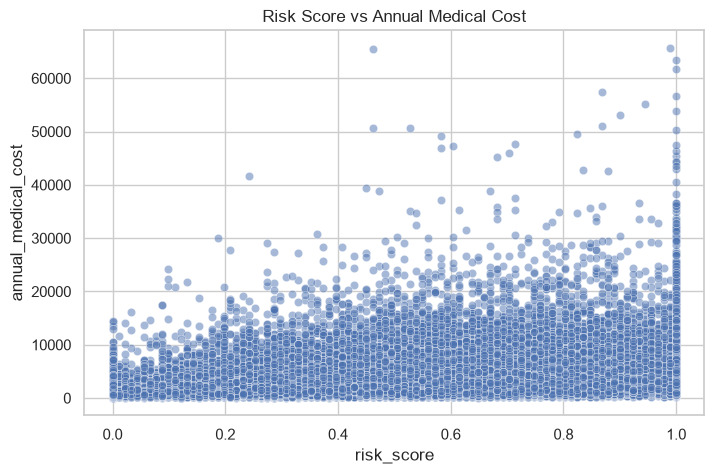

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="risk_score",
    y="annual_medical_cost",
    alpha=0.5
)

plt.title("Risk Score vs Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to visualize the relationship between `risk_score` and `annual_medical_cost`.

### 📊 Observations
- Medical cost generally increases as the risk score increases.
- Higher risk scores have more high-cost cases.
- A few high-cost outliers are present.

### 🔍 Pattern
- A strong positive relationship exists between risk score and medical cost.

### 🤖 ML Impact
- Risk score is a strong predictor of medical cost.
- It is likely to improve the model's prediction accuracy.


In [21]:
corr = df.corr(numeric_only=True)["annual_medical_cost"] \
         .sort_values(ascending=False)

corr

annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
diabetes                       0.107373
hba1c                          0.083416
asthma                         0.080830
cardiovascular_disease         0.078515
proc_surgery_count             0.076737


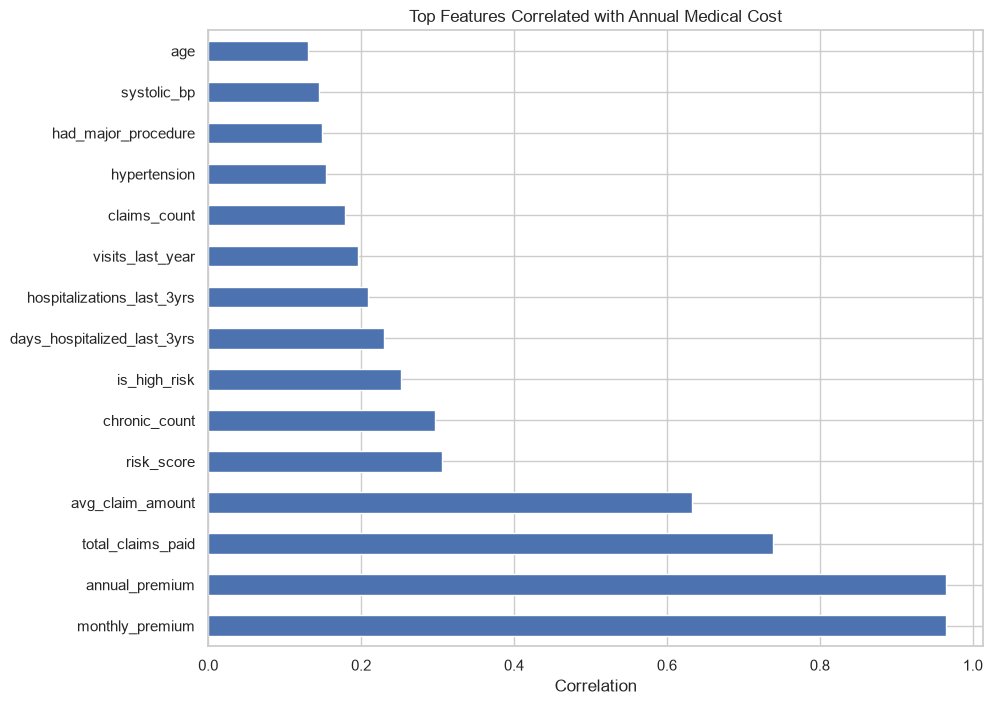

In [22]:
plt.figure(figsize=(10,8))

corr.drop("annual_medical_cost").head(15).plot(kind="barh")

plt.title("Top Features Correlated with Annual Medical Cost")

plt.xlabel("Correlation")

plt.show()

### 📊 Chart: Horizontal Bar Chart

**Purpose:** Used to compare the correlation of features with `annual_medical_cost`.

### 📊 Observations
- Monthly premium and annual premium have the highest correlation.
- Risk score and total claims paid also show strong correlation.

### 🔍 Pattern
- Features with higher correlation are more strongly related to medical cost.

### 🤖 ML Impact
- Highly correlated features are important for prediction.
- These features can improve machine learning model performance.

Multivariate_Analysis


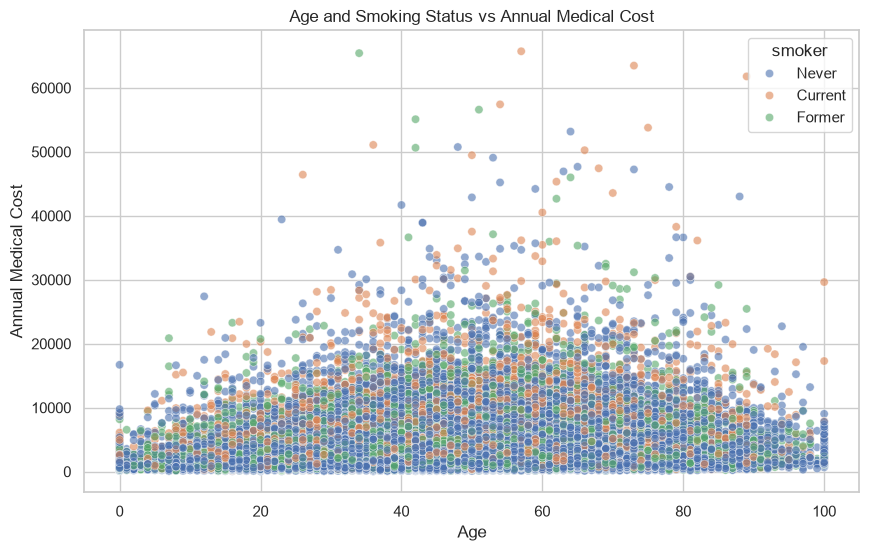

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="annual_medical_cost",
    hue="smoker",
    alpha=0.6
)

plt.title("Age and Smoking Status vs Annual Medical Cost")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to analyze the combined effect of `age` and `smoker` on `annual_medical_cost`.

### 📊 Observations
- Medical cost generally increases with age.
- Current smokers have more high-cost cases than former and never smokers.
- Older current smokers tend to have the highest medical costs.

### 🔍 Pattern
- Both age and smoking status influence annual medical cost.

### 🤖 ML Impact
- Age and smoking status are important predictors.
- Combining these features can improve model accuracy.

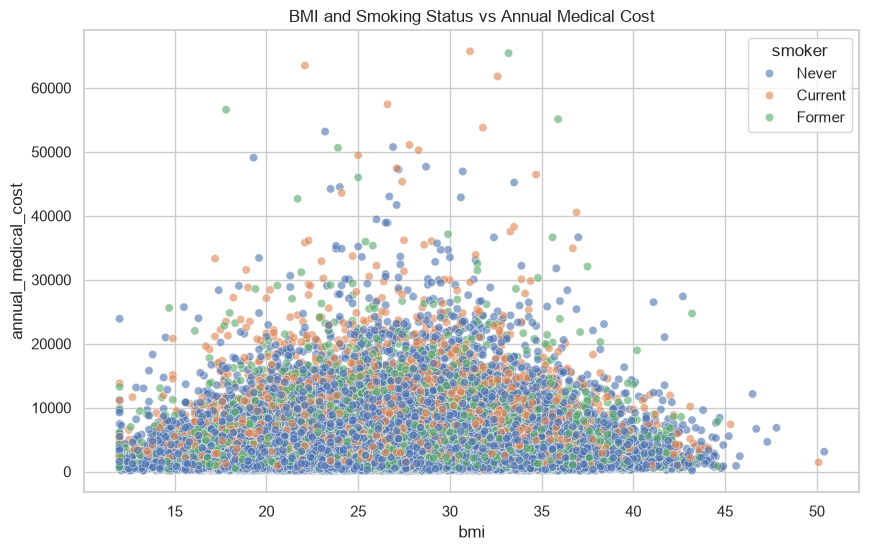

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="annual_medical_cost",
    hue="smoker",
    alpha=0.6
)

plt.title("BMI and Smoking Status vs Annual Medical Cost")

plt.show()

### 📊 Chart: Scatter Plot

**Purpose:** Used to analyze the combined effect of `BMI` and `smoker` on `annual_medical_cost`.

### 📊 Observations
- Medical cost generally increases with BMI.
- Current smokers have more high-cost cases than former and never smokers.
- High BMI current smokers tend to have the highest medical costs.

### 🔍 Pattern
- Both BMI and smoking status influence annual medical cost.

### 🤖 ML Impact
- BMI and smoking status are important predictors.
- Combining these features can improve model accuracy.

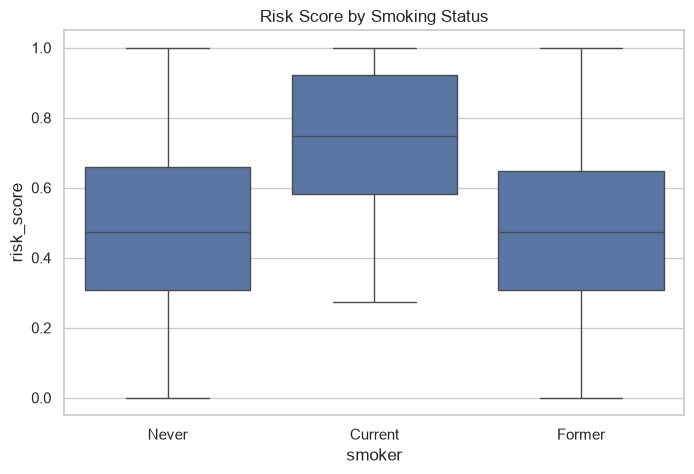

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="risk_score"
)

plt.title("Risk Score by Smoking Status")

plt.show()

### 📊 Chart: Box Plot

**Purpose:** Used to compare the distribution of `risk_score` across different smoking categories.

### 📊 Observations
- Current smokers have the highest median risk score.
- Never and Former smokers have similar risk scores.
- Current smokers show a wider spread of risk scores.

### 🔍 Pattern
- Smoking is associated with higher risk scores.

### 🤖 ML Impact
- Smoking status is an important predictor of risk.
- Risk score and smoking together can improve model performance.

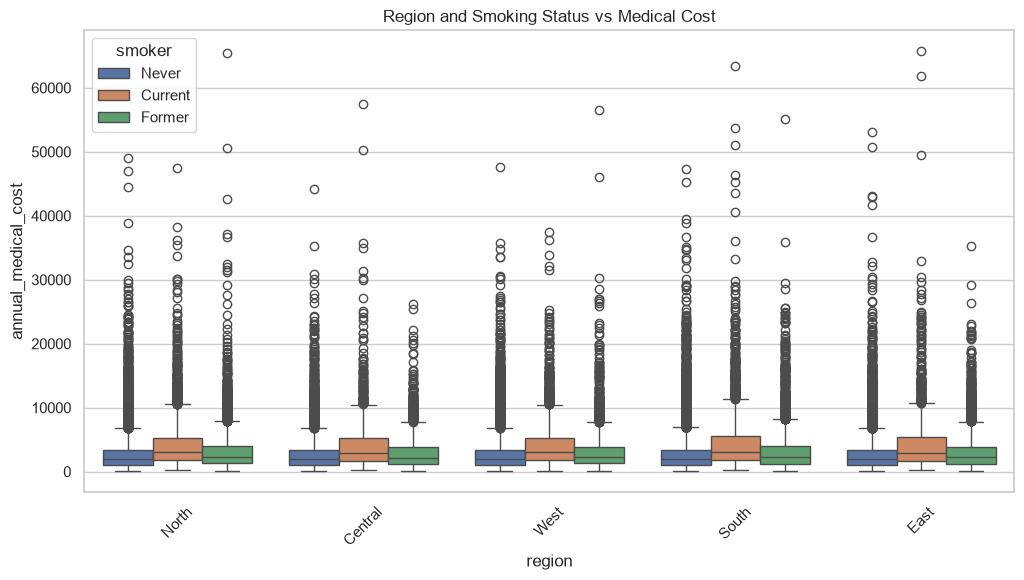

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="region",
    y="annual_medical_cost",
    hue="smoker"
)

plt.xticks(rotation=45)

plt.title("Region and Smoking Status vs Medical Cost")

plt.show()

### 📊 Chart: Grouped Box Plot

**Purpose:** Used to compare annual medical costs across different `regions` and `smoker` categories.

### 📊 Observations
- Current smokers have the highest medical costs in every region.
- South region shows slightly higher medical costs than other regions.
- Never and Former smokers have lower median costs across all regions.

### 🔍 Pattern
- Smoking has a stronger impact on medical cost than region.

### 🤖 ML Impact
- Smoking status is a key predictor of medical cost.
- Combining region and smoking status can improve model predictions.

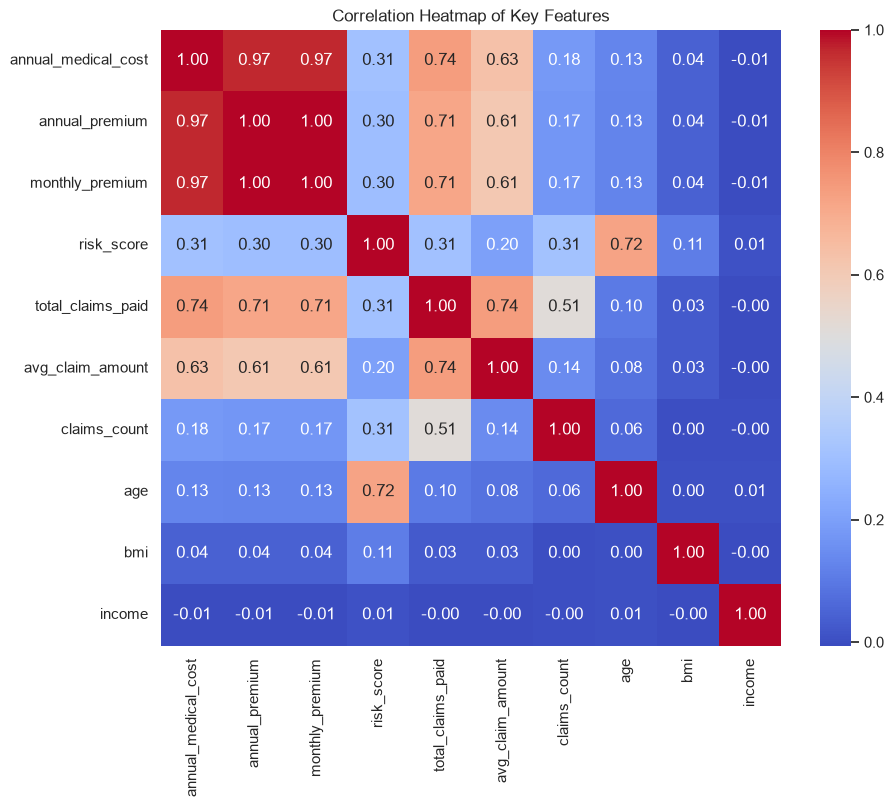

In [27]:
top_features = [
    "annual_medical_cost",
    "annual_premium",
    "monthly_premium",
    "risk_score",
    "total_claims_paid",
    "avg_claim_amount",
    "claims_count",
    "age",
    "bmi",
    "income"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Features")

plt.show()

### 📊 Chart: Correlation Heatmap

**Purpose:** Used to identify relationships between key numerical features.

### 📊 Observations
- Annual and monthly premium have the strongest positive correlation with medical cost.
- Risk score and total claims paid also show strong positive correlations.
- BMI and income have weak correlations with medical cost.

### 🔍 Pattern
- Features with higher correlation are more important for predicting medical cost.

### 🤖 ML Impact
- Highly correlated features improve prediction accuracy.
- Correlation analysis helps in feature selection before model training.

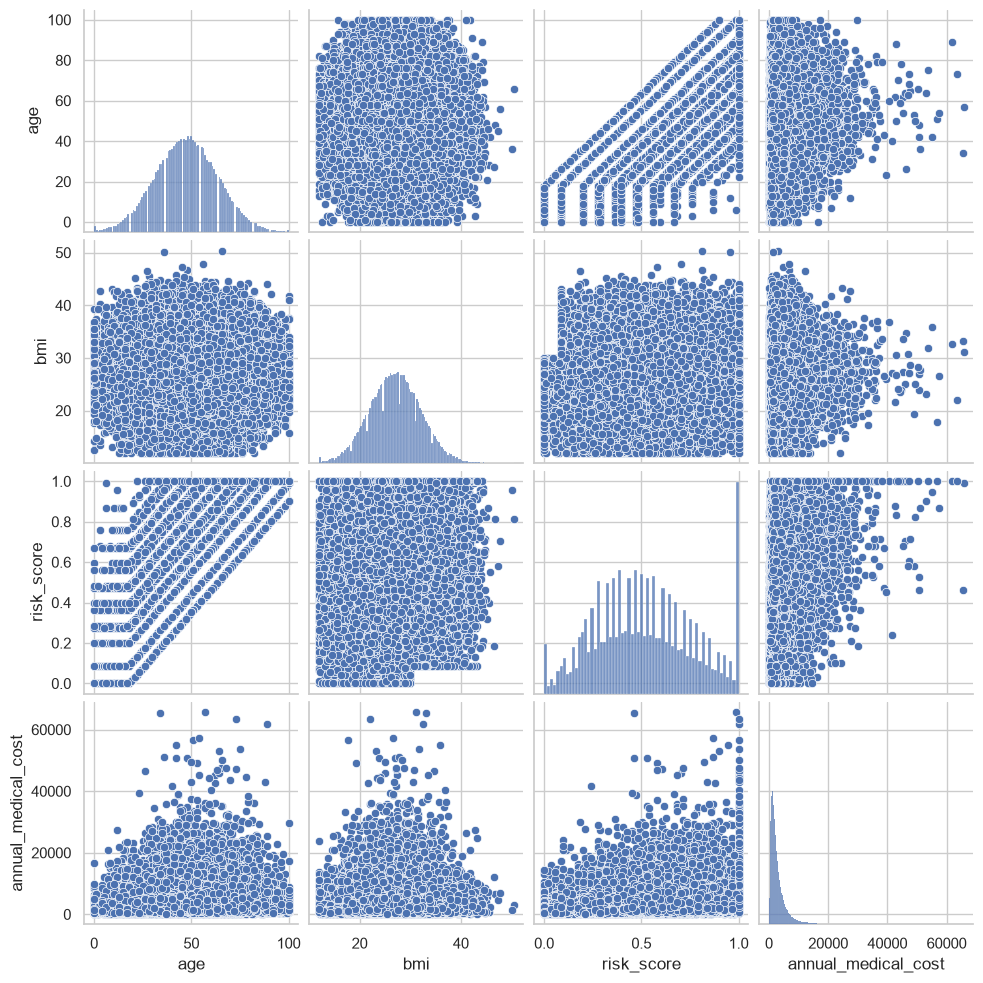

In [28]:
pair_features = [
    "age",
    "bmi",
    "risk_score",
    "annual_medical_cost"
]

sns.pairplot(df[pair_features])

plt.show()

### 📊 Chart: Pair Plot

**Purpose:** Used to visualize the distribution and relationships among multiple numerical features.

### 📊 Observations
- Age and risk score show a positive relationship.
- Risk score and medical cost increase together.
- Medical cost is right-skewed with a few high-cost outliers.

### 🔍 Pattern
- Most feature pairs have weak relationships, while risk score has a stronger relationship with medical cost.

### 🤖 ML Impact
- Helps identify important predictors and feature relationships.
- Useful for feature selection and detecting multicollinearity before model training.

# EDA Summary

## Key Findings

- Dataset contains 100,000 records and 54 features.
- No missing values or duplicate records.
- Medical cost is right-skewed with genuine high-cost outliers.
- Risk Score, Premium, Claims, Age, BMI, and Smoking Status are the strongest predictors.
- Smoking has a greater impact on medical cost than region.
- The dataset is ready for preprocessing and model building.